# 02 � Exploratory Data Analysis
Understand distributions, correlations and outliers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/listings_raw.csv')

# Keep the columns nb03 + nb04 will need. `amenities` is kept temporarily so we
# can derive n_amenities + has_* flags below, then dropped before saving.
cols = ['price', 'accommodates', 'bedrooms', 'bathrooms',
        'neighbourhood_cleansed', 'room_type', 'property_type', 'minimum_nights',
        'latitude', 'longitude',
        'availability_365', 'number_of_reviews', 'reviews_per_month',
        'host_is_superhost', 'host_response_rate', 'host_acceptance_rate',
        'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
        'review_scores_checkin', 'review_scores_communication',
        'review_scores_location', 'review_scores_value',
        'amenities']
df = df[cols].copy()
df.head()

,price,accommodates,bedrooms,bathrooms,neighbourhood_cleansed,room_type,property_type,minimum_nights,latitude,longitude,...,host_response_rate,host_acceptance_rate,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,amenities
0,NaN,4,1.0,NaN,Sihlfeld,Entire home/apt,Entire rental unit,1125,47.37167,8.51948,...,NaN,NaN,4.78,4.87,4.80,4.84,4.93,4.71,4.61,"[""Heating"", ""Elevator"", ""Dryer"", ""Kitchen"", ""H..."
1,$232.00,2,1.0,1.5,Alt-Wiedikon,Entire home/apt,Entire loft,3,47.35761,8.52131,...,100%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[""Paid parking on premises"", ""Wine glasses"", ""..."
2,$48.00,1,1.0,1.0,Enge,Private room,Private room in rental unit,5,47.36514,8.52615,...,100%,0%,4.89,4.89,4.89,4.89,4.89,5.00,4.89,"[""Heating"", ""Elevator"", ""Dryer"", ""Kitchen"", ""H..."
3,$501.00,3,2.0,1.5,Escher Wyss,Entire home/apt,Entire loft,4,47.38942,8.51881,...,NaN,NaN,4.97,5.00,4.94,4.97,4.94,4.94,4.84,"[""Mini fridge"", ""Sun loungers"", ""Coffee maker:..."
4,$160.00,4,2.0,1.0,Rathaus,Entire home/apt,Entire rental unit,4,47.37372,8.54452,...,100%,85%,4.48,4.44,4.54,4.71,4.74,4.93,4.42,"[""Heating"", ""Microwave"", ""Pets allowed"", ""Elev..."


In [2]:
# Clean price column (remove $ and commas)
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df = df[df['price'] > 0].dropna(subset=['price'])
print(df['price'].describe())

count     2592.000000
mean       181.742670
std        328.257478
min         10.000000
25%         98.000000
50%        134.000000
75%        198.250000
max      10000.000000
Name: price, dtype: float64


In [3]:
# Cap top 1% outliers
cap = df['price'].quantile(0.99)
print(f'Cap at 99th percentile: {cap:.1f} CHF')
df = df[df['price'] <= cap]
print(f'After outlier cap: {df.shape}')

Cap at 99th percentile: 801.2 CHF
After outlier cap: (2566, 24)


In [4]:
import ast
import re
from collections import Counter

# `amenities` is stored as a JSON-ish list of strings. Parse defensively
# (some rows can be malformed); fall back to splitting on commas.
def _parse_amenities(s):
    if not isinstance(s, str):
        return []
    try:
        v = ast.literal_eval(s)
        return v if isinstance(v, list) else []
    except (ValueError, SyntaxError):
        return [x.strip(' "\'[]') for x in s.split(',') if x.strip()]

amen_lists = df['amenities'].apply(_parse_amenities)
# Lowercase + strip so spelling variants don't get split across columns.
amen_lc = amen_lists.apply(lambda lst: [x.strip().lower() for x in lst if x.strip()])

df['n_amenities'] = amen_lc.apply(len)

# Top-N amenities by global frequency. Replaces the previously hand-picked
# 10 has_* flags with a wider, data-driven set so the model can learn which
# specific amenities carry signal instead of us choosing for it.
TOP_N = 30
counter = Counter(a for lst in amen_lc for a in lst)
top_amenities = [a for a, _ in counter.most_common(TOP_N)]


def _slug(s: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', s).strip('_')[:40]


# 'in' on a set is O(1), so this is far cheaper than 30 substring searches.
amen_sets = amen_lc.apply(set)
amen_cols = []
for raw in top_amenities:
    col = f'amen_{_slug(raw)}'
    amen_cols.append(col)
    df[col] = amen_sets.apply(lambda s, r=raw: int(r in s))

df = df.drop(columns=['amenities'])
print(f'Mean n_amenities: {df["n_amenities"].mean():.1f}')
print(f'\nTop-{TOP_N} amenity prevalence (column -> share of listings):')
for col, p in df[amen_cols].mean().sort_values(ascending=False).items():
    print(f'  {col:42s} {p:.3f}')

Mean n_amenities: 28.9

Top-30 amenity prevalence (column -> share of listings):
  amen_wifi                                  0.905
  amen_kitchen                               0.903
  amen_hot_water                             0.784
  amen_hair_dryer                            0.738
  amen_bed_linens                            0.717
  amen_hangers                               0.706
  amen_essentials                            0.701
  amen_cooking_basics                        0.691
  amen_refrigerator                          0.690
  amen_dishes_and_silverware                 0.668
  amen_iron                                  0.652
  amen_heating                               0.617
  amen_dedicated_workspace                   0.564
  amen_self_check_in                         0.541
  amen_long_term_stays_allowed               0.521
  amen_oven                                  0.511
  amen_shampoo                               0.507
  amen_dishwasher                            0.504
 

In [5]:
# Clean host fields:
# - host_is_superhost: 't'/'f' -> 1/0 (NaN treated as 0, i.e. "unknown != superhost")
# - host_response_rate / host_acceptance_rate: strip '%' suffix, convert to float
# review_scores_* are already float and get median-imputed inside the Pipeline.
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0).astype(int)
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = pd.to_numeric(df[col].astype(str).str.rstrip('%'), errors='coerce')

print('Host & review features prepared. NA counts after cleaning:')
na = df[['host_is_superhost', 'host_response_rate', 'host_acceptance_rate',
         'review_scores_rating', 'review_scores_cleanliness',
         'review_scores_location', 'property_type']].isna().sum()
print(na)
print(f"\nproperty_type unique values: {df['property_type'].nunique()}")

Host & review features prepared. NA counts after cleaning:
host_is_superhost              0
host_response_rate           213
host_acceptance_rate         174
review_scores_rating         614
review_scores_cleanliness    614
review_scores_location       614
property_type                  0
dtype: int64

property_type unique values: 30


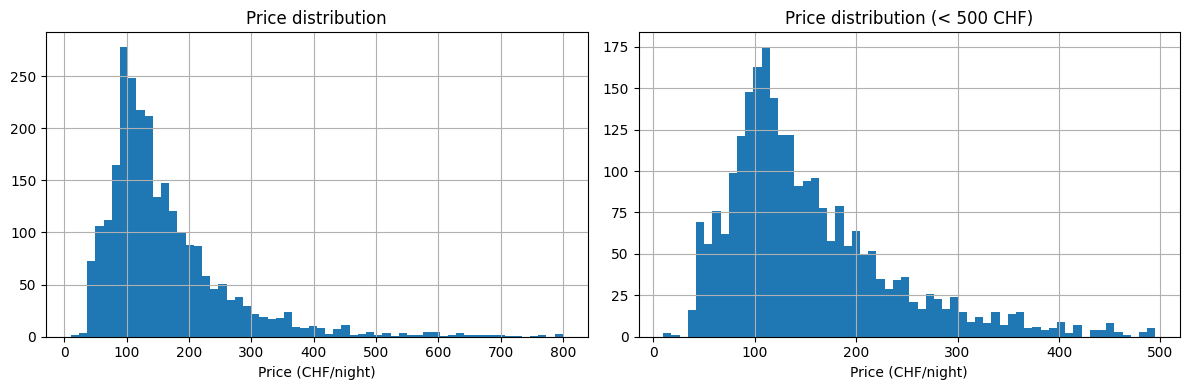

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price'].hist(bins=60, ax=axes[0])
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price (CHF/night)')

df[df['price'] < 500]['price'].hist(bins=60, ax=axes[1])
axes[1].set_title('Price distribution (< 500 CHF)')
axes[1].set_xlabel('Price (CHF/night)')
plt.tight_layout()
plt.savefig('../reports/figures/price_distribution.png', dpi=150)
plt.show()

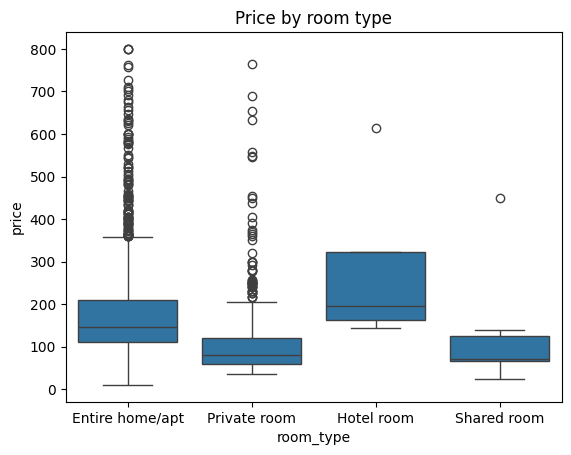

In [7]:
sns.boxplot(data=df, x='room_type', y='price')
plt.title('Price by room type')
plt.savefig('../reports/figures/price_by_room_type.png', dpi=150)
plt.show()

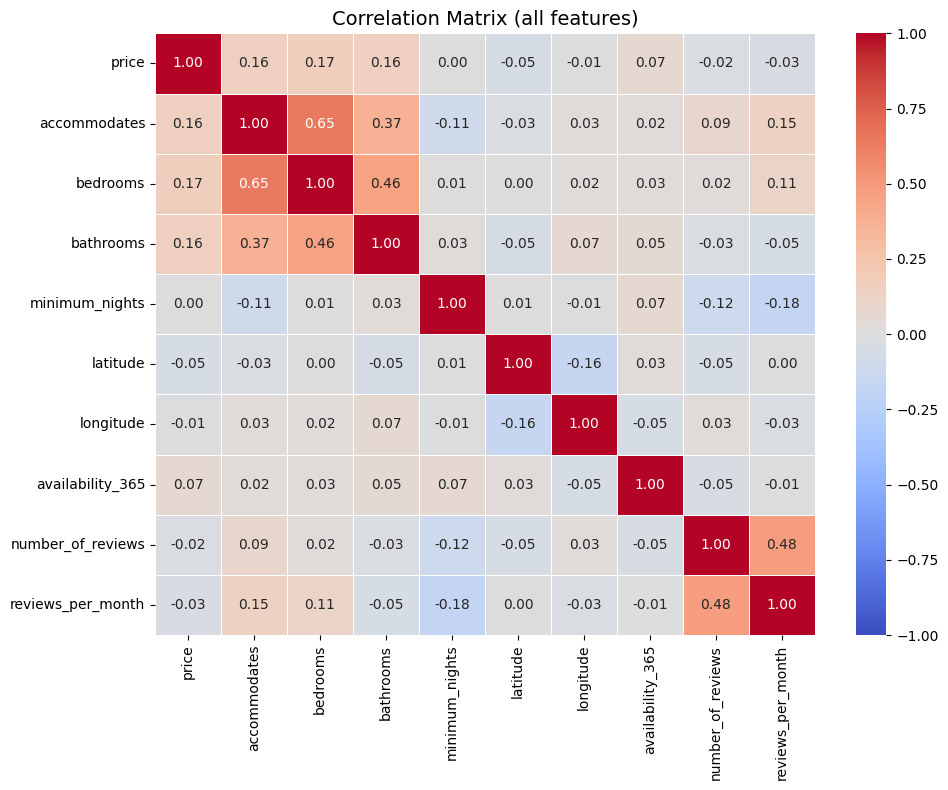

In [8]:
df_full = pd.read_csv('../data/processed/listings_raw.csv')
df_full['price'] = df_full['price'].replace('[\$,]', '', regex=True).astype(float)
df_full = df_full[df_full['price'] > 0].dropna(subset=['price'])

num_cols = ['price', 'accommodates', 'bedrooms', 'bathrooms',
            'minimum_nights', 'latitude', 'longitude',
            'availability_365', 'number_of_reviews', 'reviews_per_month']

corr = df_full[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (all features)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150)
plt.show()

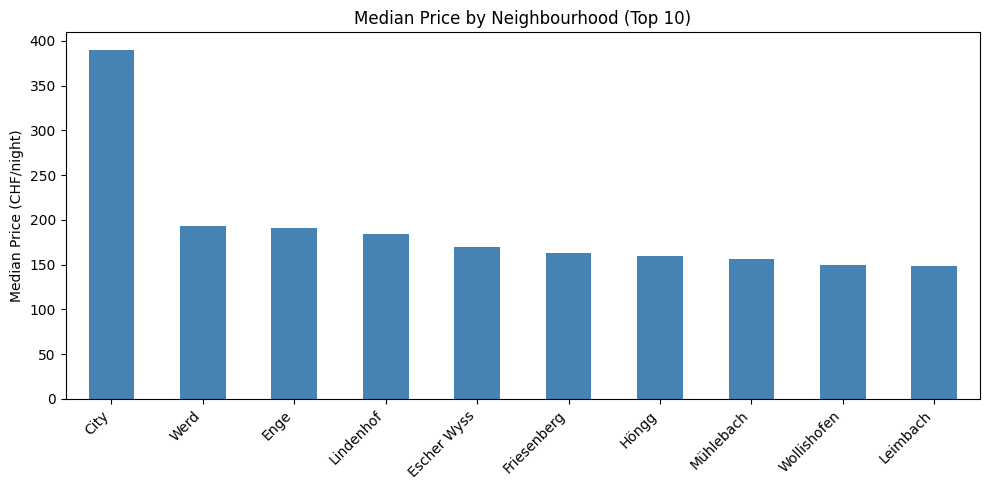

In [9]:
import matplotlib.pyplot as plt

top_n = df.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).head(10)

top_n.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Median Price by Neighbourhood (Top 10)')
plt.ylabel('Median Price (CHF/night)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/price_by_neighbourhood.png', dpi=150)
plt.show()

In [10]:
df.to_csv('../data/processed/listings_eda.csv', index=False)
print('EDA dataset saved.')

EDA dataset saved.
